# Pecan Street data analysis

Load, clean, and explore 15-minute residential electricity data. Use the helpers in `src/` (config, loaders, cleaning) then explore whole-home and circuit-level data.

## Setup

In [28]:
import sys
from pathlib import Path

# Project root = folder that contains src/ (works whether cwd is project root or notebooks/)
root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(root))

import pandas as pd
import matplotlib.pyplot as plt

from src.config import PROJECT_ROOT, WHOLE_HOME_COLUMN, DATA_PROCESSED_DIR, ALL_CIRCUIT_COLUMNS, REGIONS
from src.loaders import load_15min_data, load_metadata, merge_data_with_metadata
from src.cleaning import (
    run_cleaning_pipeline,
    get_power_columns,
    compute_data_quality_summary,
    write_cleaned_output,
)

## Part 1: Data structure and missingness

Optional row limit per region for faster runs. Then we build structure and missingness tables, save to `outputs/`, and plot missingness.

In [29]:
# Optional: limit rows per region for faster runs. Use None for full data.
SAMPLE_ROWS = None
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

In [30]:
# Build structure and missingness in one pass per region
regions = list(REGIONS.keys())
structure_rows = []
missingness_rows = []
region_dfs = {}

for region in regions:
    d = load_15min_data(region)
    if SAMPLE_ROWS is not None:
        d = d.head(SAMPLE_ROWS)
    region_dfs[region] = d
    n_rows, n_cols = d.shape
    structure_rows.append({
        "region": region,
        "n_rows": n_rows,
        "n_columns": n_cols,
        "n_homes": d["dataid"].nunique(),
        "date_min": d["local_15min"].min(),
        "date_max": d["local_15min"].max(),
    })
    for col in d.columns:
        null_count = d[col].isnull().sum()
        null_pct = (null_count / n_rows * 100) if n_rows else 0
        missingness_rows.append({
            "region": region,
            "column_name": col,
            "null_count": int(null_count),
            "null_pct": round(null_pct, 2),
            "non_null_count": int(n_rows - null_count),
        })

structure_df = pd.DataFrame(structure_rows)
missingness_df = pd.DataFrame(missingness_rows)

print("Data structure (one row per region):")
display(structure_df)
structure_df.to_csv(OUTPUTS_DIR / "data_structure_summary.csv", index=False)
print(f"Saved to {OUTPUTS_DIR / 'data_structure_summary.csv'}")

Data structure (one row per region):


,region,n_rows,n_columns,n_homes,date_min,date_max
0,austin,873286,79,25,2018-01-01 06:00:00+00:00,2019-01-01 05:45:00+00:00
1,california,805524,79,23,2014-01-01 06:00:00+00:00,2019-01-01 05:45:00+00:00
2,newyork,441599,79,25,2019-05-01 05:00:00+00:00,2019-11-01 04:45:00+00:00


Saved to /Users/cletu/Downloads/Pecan/outputs/data_structure_summary.csv


In [31]:
# Missingness: show top 20 columns by null_pct for first region; save full table
first_region = regions[0]
sub = missingness_df[missingness_df["region"] == first_region].sort_values("null_pct", ascending=False)
print(f"Top 20 columns by null % ({first_region}):")
display(sub.head(20))
missingness_df.to_csv(OUTPUTS_DIR / "missingness_summary.csv", index=False)
print(f"Saved to {OUTPUTS_DIR / 'missingness_summary.csv'}")

Top 20 columns by null % (austin):


,region,column_name,null_count,null_pct,non_null_count
37,austin,jacuzzi1,873286,100.0,0
32,austin,heater1,873286,100.0,0
30,austin,garage2,873286,100.0,0
34,austin,heater3,873286,100.0,0
35,austin,housefan1,873286,100.0,0
36,austin,icemaker1,873286,100.0,0
75,austin,wellpump1,873286,100.0,0
46,austin,lights_plugs5,873286,100.0,0
47,austin,lights_plugs6,873286,100.0,0
49,austin,livingroom2,873286,100.0,0


Saved to /Users/cletu/Downloads/Pecan/outputs/missingness_summary.csv


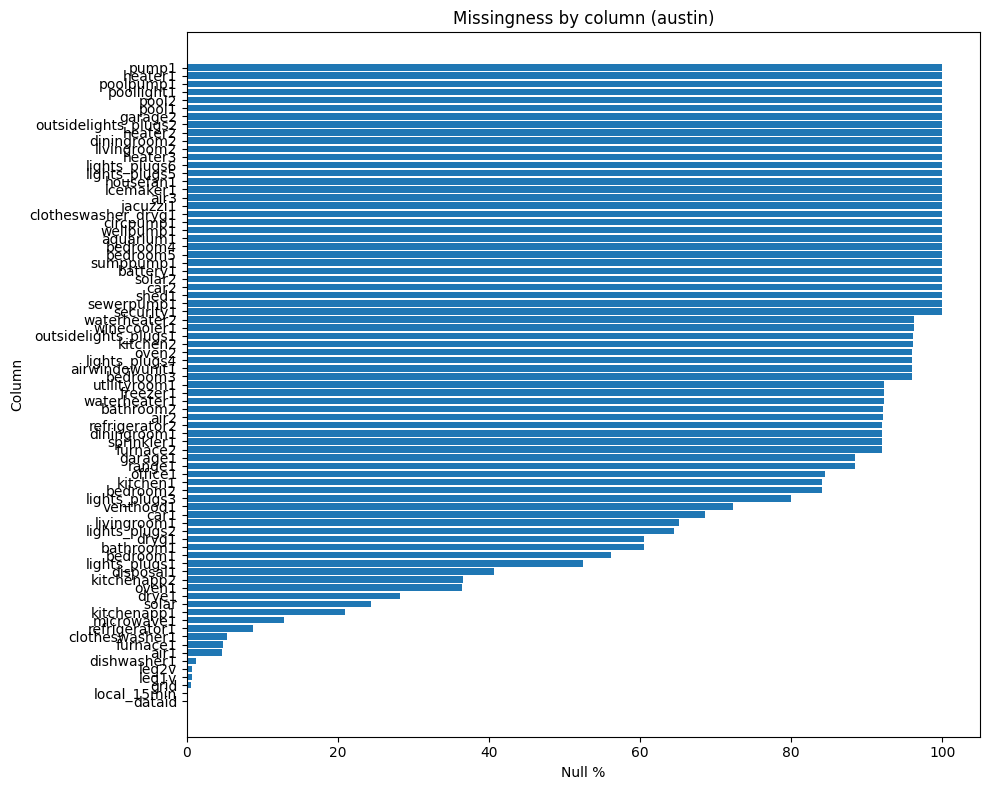

Saved to /Users/cletu/Downloads/Pecan/outputs/missingness_by_column.png


In [32]:
# Plot: missingness by column (one region, e.g. austin)
plot_region = first_region
m = missingness_df[missingness_df["region"] == plot_region].sort_values("null_pct", ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(m["column_name"], m["null_pct"])
ax.set_xlabel("Null %")
ax.set_ylabel("Column")
ax.set_title(f"Missingness by column ({plot_region})")
plt.tight_layout()
fig.savefig(OUTPUTS_DIR / "missingness_by_column.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"Saved to {OUTPUTS_DIR / 'missingness_by_column.png'}")

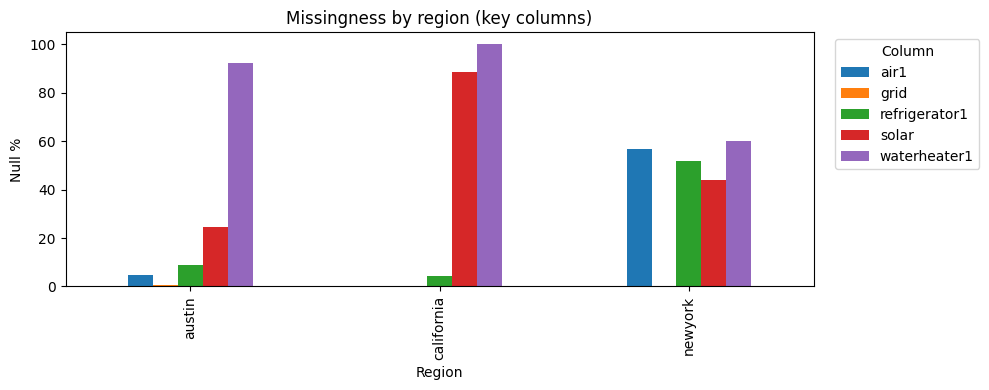

Saved to /Users/cletu/Downloads/Pecan/outputs/missingness_by_region.png


In [33]:
# Plot: missingness by region for key columns
key_cols = [c for c in ["grid", "solar", "refrigerator1", "air1", "waterheater1"] if c in missingness_df["column_name"].values]
if key_cols:
    pivot = missingness_df[missingness_df["column_name"].isin(key_cols)].pivot(index="region", columns="column_name", values="null_pct")
    pivot.plot(kind="bar", figsize=(10, 4), xlabel="Region", ylabel="Null %", title="Missingness by region (key columns)")
    plt.legend(title="Column", bbox_to_anchor=(1.02, 1))
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / "missingness_by_region.png", dpi=100, bbox_inches="tight")
    plt.show()
    print(f"Saved to {OUTPUTS_DIR / 'missingness_by_region.png'}")
else:
    print("No key columns found in missingness data.")

## Part 2: Load one region and explore

Load from `data/processed/` if cleaned file exists; otherwise load raw, merge metadata, then clean below.

In [ ]:
region = "austin"
processed_path = DATA_PROCESSED_DIR / f"cleaned_15min_{region}.csv"

if processed_path.exists():
    df = pd.read_csv(processed_path, parse_dates=["local_15min"])
    print(f"Loaded processed: {len(df):,} rows, {df['dataid'].nunique()} homes")
    used_processed = True
else:
    df = load_15min_data(region)
    if SAMPLE_ROWS is not None:
        df = df.head(SAMPLE_ROWS)
    meta = load_metadata(region)
    df = merge_data_with_metadata(df, meta, normalized=True)
    print(f"Loaded raw (sample): {len(df):,} rows, {df['dataid'].nunique()} homes")
    used_processed = False

Loaded raw (sample): 200,000 rows, 6 homes


## Clean (if using raw data)

Run the cleaning pipeline: align time to 15-min grid, clip/cap circuit values, add calendar features. Optionally save to `data/processed/`.

In [6]:
if not used_processed:
    df, quality = run_cleaning_pipeline(
        df,
        add_calendar=True,
        align_time=True,
        clip_negative_consumption=True,
        cap_percentile=99.0,
    )
    print(f"Cleaned: {len(df):,} rows. Quality summary: {quality.shape[0]} homes.")
    # Uncomment to save:
    write_cleaned_output(df, quality, region)

Cleaned: 200,000 rows. Quality summary: 6 homes.


### Preprocessing summary (saved for later)

Summary of what was loaded/cleaned for the current region; saved to `outputs/preprocessing_summary.csv`.

In [ ]:
# Preprocessing summary table (ensure outputs dir exists if Part 1 was skipped)
if "OUTPUTS_DIR" not in dir():
    OUTPUTS_DIR = PROJECT_ROOT / "outputs"
    OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
power_cols = get_power_columns(df)
preprocessing_summary = pd.DataFrame([{
    "region": region,
    "preprocessing_step": "cleaned" if not used_processed else "loaded_processed",
    "rows_after": len(df),
    "columns_kept": len(power_cols),
    "notes": "align_15min, clip_consumption, cap_99pct, calendar" if not used_processed else "read from data/processed/",
}])
display(preprocessing_summary)
preprocessing_summary.to_csv(OUTPUTS_DIR / "preprocessing_summary.csv", index=False)
print(f"Saved to {OUTPUTS_DIR / 'preprocessing_summary.csv'}")

# Optional: short report listing output files
from datetime import datetime
report = f"""# Analysis report
Generated: {datetime.now().isoformat()}

| File | Description |
|------|-------------|
| data_structure_summary.csv | One row per region: n_rows, n_columns, n_homes, date range |
| missingness_summary.csv | Per region per column: null_count, null_pct, non_null_count |
| preprocessing_summary.csv | Preprocessing step and row/column counts for current run |
| missingness_by_column.png | Bar chart of null % by column (one region) |
| missingness_by_region.png | Bar chart of null % for key columns by region |
"""
(OUTPUTS_DIR / "analysis_report.md").write_text(report)
print(f"Saved to {OUTPUTS_DIR / 'analysis_report.md'}")

## Basic exploration

### Whole-home (grid) load shape by hour

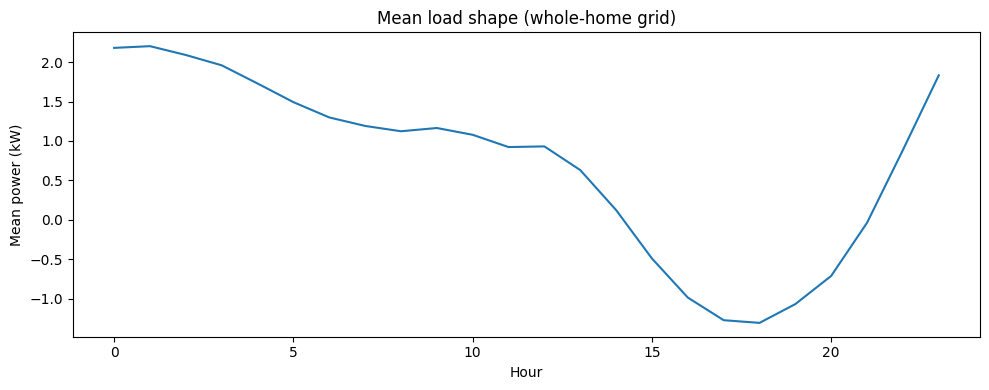

In [ ]:
if WHOLE_HOME_COLUMN in df.columns:
    by_hour = df.groupby(df["local_15min"].dt.hour)[WHOLE_HOME_COLUMN].mean()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(by_hour.index, by_hour.values)
    ax.set_xlabel("Hour")
    ax.set_ylabel("Mean power (kW)")
    ax.set_title("Mean load shape (whole-home grid)")
    plt.tight_layout()
    plt.show()

### Sample circuits over time (one home)

Plot grid and one or two other circuits for a single home to see patterns.

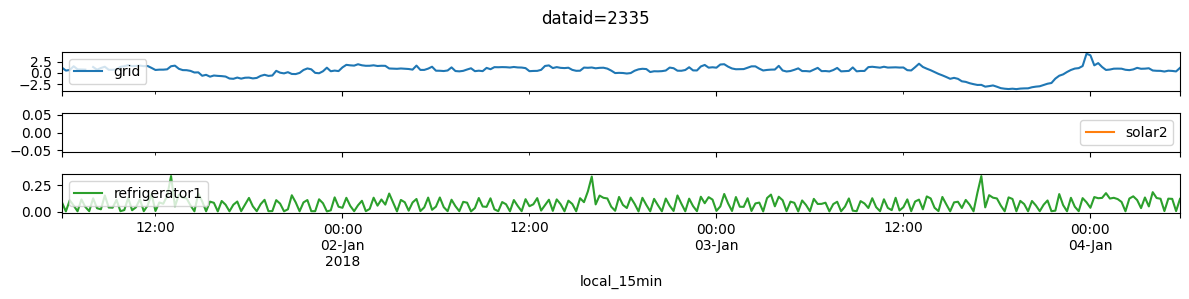

In [ ]:
# sample
sample_id = df["dataid"].iloc[0]
subset = df[df["dataid"] == sample_id].sort_values("local_15min").head(4 * 24 * 3)  # up to 3 days
cols_to_plot = [c for c in [WHOLE_HOME_COLUMN, "solar", "solar2", "car1", "refrigerator1"] if c in subset.columns][:4]
if cols_to_plot:
    subset.set_index("local_15min")[cols_to_plot].plot(figsize=(12, 3), subplots=True, sharex=True)
    plt.suptitle(f"dataid={sample_id}")
    plt.tight_layout()
    plt.show()
else:
    print("No circuit columns to plot.")

### Power circuits: list and presence

All circuit columns (excluding id, time, voltage) and what share of rows have non-null values.

In [ ]:
power_cols = get_power_columns(df)
print(f"Circuits in config: {len(ALL_CIRCUIT_COLUMNS)}. Present in this data: {len(power_cols)}.")
if power_cols:
    presence = df[power_cols].notna().mean().sort_values(ascending=False)
    display(presence.head(25))
else:
    print("No power columns found.")

Circuits in config: 75. Present in this data: 68.


air1              0.995075
grid              0.995075
dishwasher1       0.966670
refrigerator1     0.966670
microwave1        0.966670
clotheswasher1    0.966090
furnace1          0.851310
kitchenapp1       0.851030
oven1             0.821575
drye1             0.820160
venthood1         0.689525
bathroom1         0.678850
kitchenapp2       0.676130
dryg1             0.632405
disposal1         0.624385
freezer1          0.290120
livingroom1       0.282585
sprinkler1        0.174900
bedroom1          0.174740
lights_plugs1     0.174740
lights_plugs2     0.174740
oven2             0.172335
utilityroom1      0.167385
winecooler1       0.115200
waterheater2      0.115200
dtype: float64

### Metadata and date range

In [10]:
n_homes = df["dataid"].nunique()
date_min = df["local_15min"].min()
date_max = df["local_15min"].max()
print(f"Homes: {n_homes}")
print(f"Date range: {date_min} to {date_max}")
if "building_type" in df.columns:
    print(df["building_type"].value_counts().head())

Homes: 6
Date range: 2018-01-01 06:00:00+00:00 to 2019-01-01 05:45:00+00:00
building_type
Single-Family Home 001 (Master)    200000
Name: count, dtype: int64


### Data quality summary (optional)

Per-home: total intervals, valid grid %, date range.

In [11]:
quality = compute_data_quality_summary(df)
display(quality.head(10))

,total_intervals,valid_grid_intervals,pct_valid_grid,date_min,date_max
dataid,,,,,
661,35032,34700,99.05,2018-01-01 06:00:00+00:00,2019-01-01 05:45:00+00:00
1642,34648,34468,99.48,2018-01-01 06:00:00+00:00,2019-01-01 05:45:00+00:00
2335,34468,34467,100.00,2018-01-01 06:00:00+00:00,2019-01-01 05:45:00+00:00
2361,34984,34984,100.00,2018-01-01 06:00:00+00:00,2019-01-01 05:45:00+00:00
2818,34980,34980,100.00,2018-01-01 06:00:00+00:00,2019-01-01 05:45:00+00:00
3039,25888,25416,98.18,2018-01-01 06:00:00+00:00,2018-09-27 21:45:00+00:00
